# SpatialData notebook

This notebook is an introductory tutorial to the [`SpatialData`](https://spatialdata.scverse.org/) framework, a data model and Python library for storing, manipulating, and visualizing multi-modal spatial omics data (images, labels, points, shapes, and annotated tables) in a single, on-disk `.zarr` store.

It uses a downsampled 10x Genomics Xenium (spatial transcriptomics) dataset to demonstrate the core building blocks of a `SpatialData` object and the most common operations performed on one.






## Intro to SpatialData

In [1]:
import spatialdata as sd
import spatialdata_plot 

The data used in this notebook can be downloaded from this side:

### Exploring the SpatialData

In [2]:
data_path = "./DownsampledData_Xenium/xenium_ds_workshop_updated.zarr"
sdata = sd.read_zarr(data_path)
sdata

no parent found for <ome_zarr.reader.Label object at 0x000001ADDA64BD40>: None
no parent found for <ome_zarr.reader.Label object at 0x000001ADDA70B920>: None


SpatialData object, with associated Zarr store: C:\Users\krili463\Documents\GIT_repos\other\I2KWorkshop_2026\DownsampledData_Xenium\xenium_ds_workshop_updated.zarr
├── Images
│     ├── 'he_image': DataArray[cyx] (3, 11272, 2895)
│     └── 'morphology_focus': DataTree[cyx] (4, 4274, 12796), (4, 2137, 6398), (4, 1068, 3199), (4, 534, 1599), (4, 267, 799)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (4275, 12797), (2137, 6398), (1068, 3199), (534, 1599), (267, 799)
│     └── 'nucleus_labels': DataTree[yx] (4275, 12797), (2137, 6398), (1068, 3199), (534, 1599), (267, 799)
├── Points
│     └── 'transcripts': DataFrame with shape: (3041266, 11) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (162254, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (162254, 377)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shape

### Explore the `Elements` of the `SpatialData` object


#### Images

We can access elements using keys e.g. `sdata[key]`, similar to dictionaries.

In [3]:
sdata["he_image"]

<xarray.DataArray 'image' (c: 3, y: 11272, x: 2895)> Size: 98MB
dask.array<from-zarr, shape=(3, 11272, 2895), dtype=uint8, chunksize=(3, 4096, 2895), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U1 12B 'r' 'g' 'b'
  * y        (y) float64 90kB 0.5 1.5 2.5 3.5 ... 1.127e+04 1.127e+04 1.127e+04
  * x        (x) float64 23kB 0.5 1.5 2.5 3.5 ... 2.892e+03 2.894e+03 2.894e+03
Attributes:
    transform:  {'global': Sequence \n    Affine (c, y, x -> c, x, y)\n      ...

In [4]:
sdata["morphology_focus"]

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 4, y: 4274, x: 12796)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 34kB 0.5 1.5 2.5 3.5 ... 4.272e+03 4.272e+03 4.274e+03
│         * x        (x) float64 102kB 0.5 1.5 2.5 3.5 ... 1.279e+04 1.279e+04 1.28e+04
│       Data variables:
│           image    (c, y, x) uint16 438MB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (c: 4, y: 2137, x: 6398)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 17kB 1.0 3.0 5.0 7.0 ... 4.269e+03 4.271e+03 4.273e+03
│         * x        (x) float64 51kB 1.0 3.0 5.0 7.0 ... 1.279e+04 1.279e+04 1.28e+04
│       Data variables:
│           image    (c, y, x) uint16 109MB dask.array<chunksize=(1, 2137, 4096), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (c: 4, y: 1068, x: 3199)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 9kB 2.001 6.003 10.0 ... 4.264e+03 4.268e+03 4.272e+03
│         * x        (x) float64 26kB 2.0 6.0 10.0 ... 1.279e+04 1.279e+04 1.279e+04
│       Data variables:
│           image    (c, y, x) uint16 27MB dask.array<chunksize=(1, 1068, 3199), meta=np.ndarray>
├── Group: /scale3
│       Dimensions:  (c: 4, y: 534, x: 1599)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 4kB 4.002 12.01 20.01 ... 4.254e+03 4.262e+03 4.27e+03
│         * x        (x) float64 13kB 4.001 12.0 20.01 ... 1.278e+04 1.278e+04 1.279e+04
│       Data variables:
│           image    (c, y, x) uint16 7MB dask.array<chunksize=(1, 534, 1599), meta=np.ndarray>
└── Group: /scale4
        Dimensions:  (c: 4, y: 267, x: 799)
        Coordinates:
          * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
          * y        (y) float64 2kB 8.004 24.01 40.02 ... 4.234e+03 4.25e+03 4.266e+03
          * x        (x) float64 6kB 8.008 24.02 40.04 ... 1.276e+04 1.277e+04 1.279e+04
        Data variables:
            image    (c, y, x) uint16 2MB dask.array<chunksize=(1, 267, 799), meta=np.ndarray>

In this case, our image has 5 scales. Let's access the highest resolution image.

In [5]:
sd.get_pyramid_levels(sdata["morphology_focus"], n=0)

<xarray.DataArray 'image' (c: 4, y: 4274, x: 12796)> Size: 438MB
dask.array<from-zarr, shape=(4, 4274, 12796), dtype=uint16, chunksize=(1, 4096, 4096), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
  * y        (y) float64 34kB 0.5 1.5 2.5 3.5 ... 4.272e+03 4.272e+03 4.274e+03
  * x        (x) float64 102kB 0.5 1.5 2.5 3.5 ... 1.279e+04 1.279e+04 1.28e+04
Attributes:
    transform:  {'global': Identity }

To view image properties such as axes and channel names, `SpatialData` provides some helper functions. More helper functions can be found in the [API](../../../../api.md) page.

In [6]:
sd.models.get_axes_names(sdata["morphology_focus"])

('c', 'y', 'x')

Here we see that our image only has one channel for DAPI staining.


In [7]:

sd.models.get_channel_names(sdata["he_image"])

['r', 'g', 'b']

In [8]:
sd.models.get_channel_names(sdata["morphology_focus"])

['DAPI', 'ATP1A1/CD45/E-Cadherin', '18S', 'AlphaSMA/Vimentin']

Let's use `spatialdata-plot` to show the image.

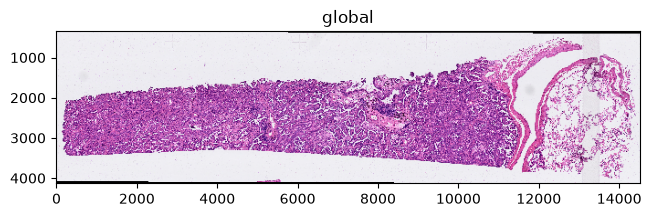

In [9]:
# plot the image in color

sdata.pl.render_images("he_image").pl.show()

#### Labels

In [10]:
sdata["cell_labels"]

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (y: 4275, x: 12797)
│       Coordinates:
│         * y        (y) float64 34kB 0.5 1.5 2.5 3.5 ... 4.272e+03 4.274e+03 4.274e+03
│         * x        (x) float64 102kB 0.5 1.5 2.5 3.5 ... 1.279e+04 1.28e+04 1.28e+04
│       Data variables:
│           image    (y, x) uint32 219MB dask.array<chunksize=(4096, 4096), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (y: 2137, x: 6398)
│       Coordinates:
│         * y        (y) float64 17kB 1.0 3.001 5.001 ... 4.27e+03 4.272e+03 4.274e+03
│         * x        (x) float64 51kB 1.0 3.0 5.0 7.001 ... 1.279e+04 1.279e+04 1.28e+04
│       Data variables:
│           image    (y, x) uint32 55MB dask.array<chunksize=(2137, 4096), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (y: 1068, x: 3199)
│       Coordinates:
│         * y        (y) float64 9kB 2.001 6.004 10.01 ... 4.265e+03 4.269e+03 4.273e+03
│         * x        (x) float64 26kB 2.0 6.0 10.0 ... 1.279e+04 1.279e+04 1.279e+04
│       Data variables:
│           image    (y, x) uint32 14MB dask.array<chunksize=(1068, 3199), meta=np.ndarray>
├── Group: /scale3
│       Dimensions:  (y: 534, x: 1599)
│       Coordinates:
│         * y        (y) float64 4kB 4.003 12.01 20.01 ... 4.255e+03 4.263e+03 4.271e+03
│         * x        (x) float64 13kB 4.002 12.0 20.01 ... 1.278e+04 1.278e+04 1.279e+04
│       Data variables:
│           image    (y, x) uint32 3MB dask.array<chunksize=(534, 1599), meta=np.ndarray>
└── Group: /scale4
        Dimensions:  (y: 267, x: 799)
        Coordinates:
          * y        (y) float64 2kB 8.006 24.02 40.03 ... 4.235e+03 4.251e+03 4.267e+03
          * x        (x) float64 6kB 8.008 24.02 40.04 ... 1.276e+04 1.277e+04 1.279e+04
        Data variables:
            image    (y, x) uint32 853kB dask.array<chunksize=(267, 799), meta=np.ndarray>

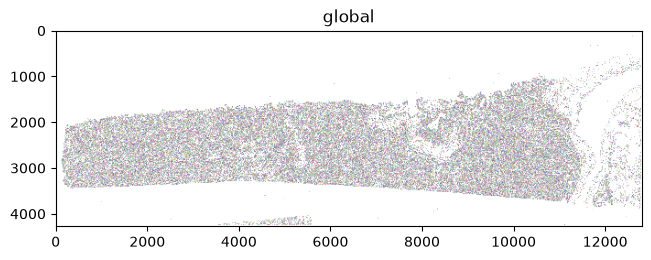

In [11]:
sdata.pl.render_labels().pl.show()

#### Points

Points are represented as `dask.DataFrame` objects containing point coordinates.

In [12]:
sdata["transcripts"]

,x,y,z,feature_name,cell_id,nucleus_distance,overlaps_nucleus,codeword_index,qv,transcript_id,fov_name
npartitions=1,,,,,,,,,,,
,float32,float32,float32,category[unknown],string,float32,uint8,int32,float32,uint64,string
,...,...,...,...,...,...,...,...,...,...,...


In [13]:
sdata["transcripts"].head()

,x,y,z,feature_name,cell_id,nucleus_distance,overlaps_nucleus,codeword_index,qv,transcript_id,fov_name
0,9945.654297,2.447187,13.160189,MYC,UNASSIGNED,274.256165,0,280,38.001629,281474976713526,A18
1,10127.627930,6.606582,12.549275,MPEG1,UNASSIGNED,275.866150,0,111,40.000000,281474976715544,A18
2,10621.109375,8.324492,12.747325,PPARG,UNASSIGNED,433.976898,0,327,40.000000,281479271683775,A19
3,9899.828125,10.202562,12.981535,CYP4B1,UNASSIGNED,268.330750,0,332,40.000000,281474976718000,A18
4,10380.220703,12.465999,13.039993,LTBP2,UNASSIGNED,414.773804,0,232,40.000000,281479271684611,A19


In [14]:
sdata["transcripts"].compute()

,x,y,z,feature_name,cell_id,nucleus_distance,overlaps_nucleus,codeword_index,qv,transcript_id,fov_name
0,9945.654297,2.447187,13.160189,MYC,UNASSIGNED,274.256165,0,280,38.001629,281474976713526,A18
1,10127.627930,6.606582,12.549275,MPEG1,UNASSIGNED,275.866150,0,111,40.000000,281474976715544,A18
2,10621.109375,8.324492,12.747325,PPARG,UNASSIGNED,433.976898,0,327,40.000000,281479271683775,A19
3,9899.828125,10.202562,12.981535,CYP4B1,UNASSIGNED,268.330750,0,332,40.000000,281474976718000,A18
4,10380.220703,12.465999,13.039993,LTBP2,UNASSIGNED,414.773804,0,232,40.000000,281479271684611,A19
...,...,...,...,...,...,...,...,...,...,...,...
3041261,9675.743164,3624.525146,13.007014,MLPH,UNASSIGNED,224.295578,0,112,18.648043,281728379806990,E18
3041262,9268.542969,3625.122314,12.875487,AQP3,UNASSIGNED,178.995178,0,94,17.799042,281724084840136,E17
3041263,10766.286133,3626.107422,12.420681,CRISPLD2,UNASSIGNED,293.853363,0,207,40.000000,281732674779290,E19
3041264,9747.374023,3626.963135,12.824594,EDNRB,UNASSIGNED,295.838470,0,202,38.320213,281728379819033,E18


Let's visualize the points. 

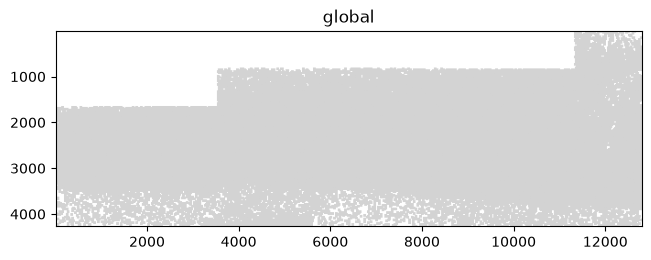

In [15]:
sdata.pl.render_points("transcripts").pl.show()

Let's plot the transcripts colored by gene. We can also use the `groups` argument to plot transcripts for a subset of genes.


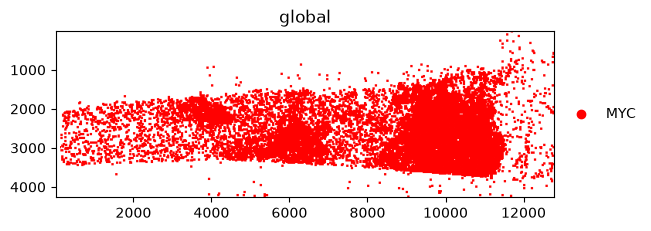

In [16]:
sdata.pl.render_points("transcripts", color="feature_name", groups="MYC", palette="red").pl.show()

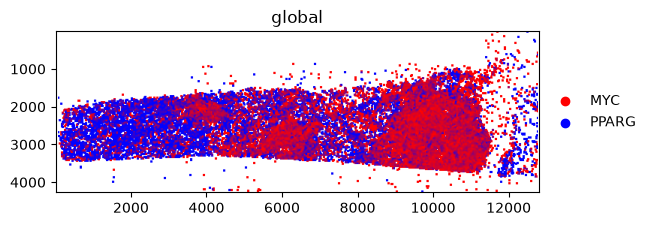

In [17]:
# plot similar to the above but with more feature names
sdata.pl.render_points("transcripts", color="feature_name", groups=["MYC", "PPARG"], palette=["red","blue"]).pl.show()


### Shapes

Shapes are represented as `geopandas.GeoDataFrame` objects containing geometric objects like polygons.

In [18]:
sdata["cell_boundaries"]

,geometry
cell_id,
aaaadpbp-1,"POLYGON ((205.062 1489.838, 204.213 1490.475, ..."
aaaaficg-1,"POLYGON ((200.812 1811.988, 199.538 1812.625, ..."
aaabbaka-1,"POLYGON ((177.013 2158.575, 175.525 2159.425, ..."
aaabbjoo-1,"POLYGON ((185.513 2156.238, 184.238 2157.3, 18..."
aaablchg-1,"POLYGON ((197.2 2191.938, 197.413 2192.15, 197..."
...,...
ojaaphhh-1,"POLYGON ((4551.538 1640.925, 4551.325 1641.138..."
ojabeldf-1,"POLYGON ((4437.212 1627.75, 4437 1627.963, 443..."
ojacfbid-1,"POLYGON ((4462.712 1575.05, 4462.288 1575.475,..."


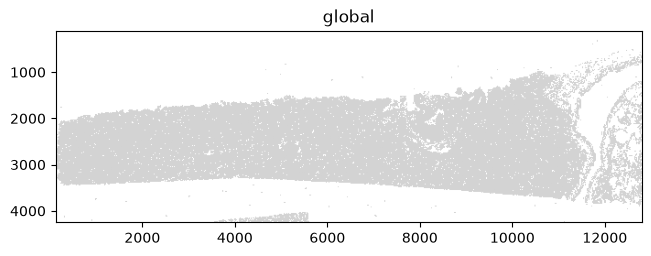

In [19]:
sdata.pl.render_shapes("cell_boundaries").pl.show()

### Tables

Annotated matrices are represented as `anndata.AnnData` objects. 

In [20]:
sdata["table"]

AnnData object with n_obs × n_vars = 162254 × 377
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'
    layers: None (.X)

Here is an example of plotting numerical information on the cells ("EPCAM" gene expression).

In [21]:
# The table currently annotates the `cell_labels` element, not `cell_boundaries`,
# so `render_shapes(..., color=...)` can't find a table to pull column values from.
# `cell_id` matches the `cell_boundaries` index, so re-point the table's annotation target to it.
sdata["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries", instance_key="cell_id")

c:\Users\krili463\Documents\GIT_repos\other\I2KWorkshop_2026\.pixi\envs\default\Lib\site-packages\spatialdata\_core\spatialdata.py:477: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


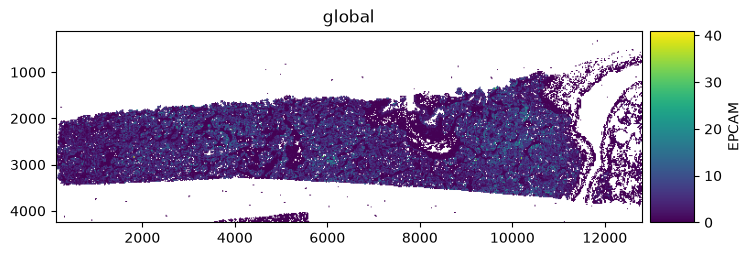

In [22]:
sdata.pl.render_shapes("cell_boundaries", color="EPCAM").pl.show()

Now is an example of plotting categorical information (cell labels).

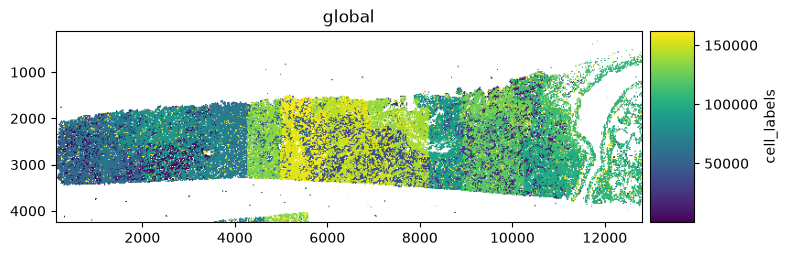

In [23]:
sdata.pl.render_shapes("cell_boundaries", color="cell_labels").pl.show()

Let's visualize all the layers together. We can easily chain the operations to render multiple `Elements` overlayed on top of each other in the same plot.

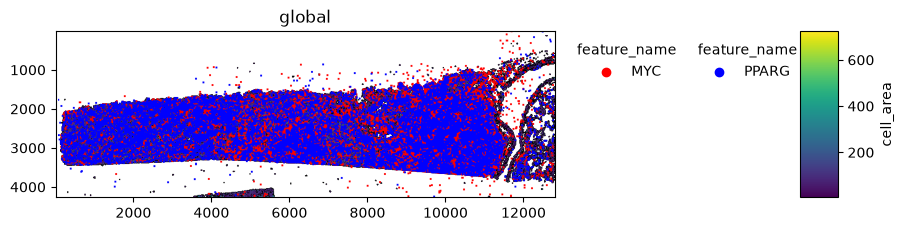

In [24]:
(
    sdata.pl.render_shapes(
        "cell_boundaries",
        color="cell_area",
        outline_alpha=1.0,
        outline_width=0.5,
    )
    .pl.render_points(
        "transcripts",
        color="feature_name", 
        groups="MYC",
        palette="red",
    )
    .pl.render_points(
        "transcripts",
        color="feature_name",
        groups="PPARG",
        palette="blue",
    )
    .pl.show(figsize=(8, 8))
)

## Spatial Querying and Subsetting

Given a single-modal or multi-modal dataset, spatial queries allow to retrieve all the spatial elements and instances that are within a given rectangular window or polygonal shape.


In [25]:
sd.get_extent(sdata)

{'y': (np.float64(0.0), np.float64(4275.0)),
 'x': (np.float64(-18.8705056342), np.float64(14521.48004280448)),
 'z': (np.float64(4.722587585449219), np.float64(32.4763069152832))}

To perform a bounding box query, we provide the axes, min/max coordinates, and the target coordinate system for the bounding box coordinates.


In [26]:
crop_sdata1 = sd.bounding_box_query(
    sdata, axes=("y", "x"), min_coordinate=[1500, 1500], max_coordinate=[2000, 2000], target_coordinate_system="global"
)
crop_sdata1

SpatialData object
├── Images
│     ├── 'he_image': DataArray[cyx] (3, 390, 390)
│     └── 'morphology_focus': DataTree[cyx] (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 63, 63), (4, 31, 31)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (500, 500), (250, 250), (125, 125), (63, 63), (31, 31)
│     └── 'nucleus_labels': DataTree[yx] (500, 500), (250, 250), (125, 125), (63, 63), (31, 31)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 11) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (614, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (614, 377)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes)

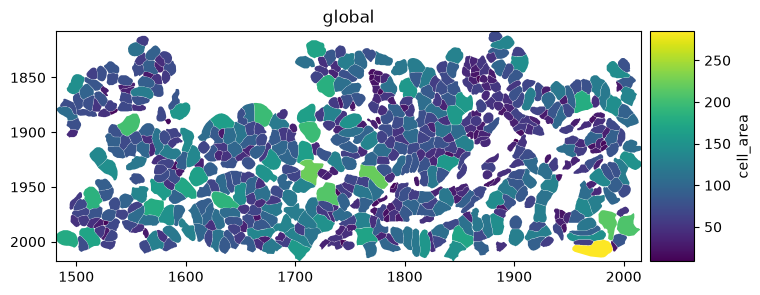

In [27]:
crop_sdata1.pl.render_shapes("cell_boundaries", color="cell_area").pl.show()

Similarly, we can perform a polygon query by using a `shapely.Polygon` object and passing the target coordinate system.

In [28]:
from shapely import Polygon

polygon = Polygon([(1000, 1000), (1500, 1000), (2000, 1500), (1500, 2000)])
crop_sdata2 = sd.polygon_query(sdata, polygon, target_coordinate_system="global")
crop_sdata2

SpatialData object
├── Images
│     ├── 'he_image': DataArray[cyx] (3, 779, 779)
│     └── 'morphology_focus': DataTree[cyx] (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 63, 63)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (1000, 1000), (500, 500), (250, 250), (125, 125), (63, 63)
│     └── 'nucleus_labels': DataTree[yx] (1000, 1000), (500, 500), (250, 250), (125, 125), (63, 63)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 11) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (127, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (127, 377)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes)

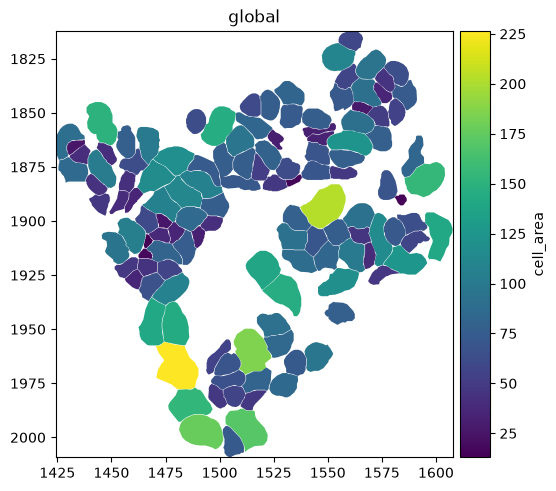

In [29]:
crop_sdata2.pl.render_shapes("cell_boundaries", color="cell_area").pl.show()

### Saving `SpatialData` Objects

Currently, the cropped `SpatialData` object only exists in memory. Let's save it by writing it to disk in a new `.zarr` store.

> **Note**
>
> It is not recommended to modify this in place. For more information on incremental reading and writing of `SpatialData` objects, [see more here](https://github.com/scverse/spatialdata/discussions/520).

In [30]:
from pathlib import Path
from tempfile import TemporaryDirectory

tmpdir = TemporaryDirectory()
crop_sdata2.write(Path(tmpdir.name) / "crop.zarr")

c:\Users\krili463\Documents\GIT_repos\other\I2KWorkshop_2026\.pixi\envs\default\Lib\site-packages\dask\utils.py:782: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Scale is not JSON serializable, defaulting to empty attributes.
  return meth(arg, *args, **kwargs)
c:\Users\krili463\Documents\GIT_repos\other\I2KWorkshop_2026\.pixi\envs\default\Lib\site-packages\dask\dataframe\io\parquet\arrow.py:824: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Scale is not JSON serializable, defaulting to empty attributes.
  t = cls._pandas_to_arrow_table(df, preserve_index=preserve_index, schema=schema)
